In [3]:
from pathlib import Path
import pandas as pd
import zipfile
from collections import Counter
import matplotlib.pyplot as plt
import csv

For event id_16:
- what type of event is it?
- which channels are associated with it?
- which subsystems are involved?
- what happened before the event?
- what happened during the event?
- what happened after the event?
- were telecommands nearby?
- which channel changed first?
- did channels recover?

In [4]:
labelled_channels = pd.read_csv("/Volumes/StudyNProjects/Python/ESA-Mission1/labels.csv")
anamoly_types = pd.read_csv("/Volumes/StudyNProjects/Python/ESA-Mission1/anomaly_types.csv")
channels = pd.read_csv("/Volumes/StudyNProjects/Python/ESA-Mission1/channels.csv")
telecommand = pd.read_csv("/Volumes/StudyNProjects/Python/ESA-Mission1/telecommands.csv")
telecommand_folder = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/telecommands")
unzip_telecommand = list(telecommand_folder.glob("*.zip"))
channel_folder = Path("/Volumes/StudyNProjects/Python/ESA-Mission1/channels")
unzip_channel = list(channel_folder.glob("*.zip"))

What type of Event it is?

In [39]:
filter_labelled_event = labelled_channels["ID"] == "id_9"
selected_labelled_event = labelled_channels[filter_labelled_event]
selected_labelled_event["StartTime"] = pd.to_datetime(selected_labelled_event["StartTime"])
selected_labelled_event["EndTime"] = pd.to_datetime(selected_labelled_event["EndTime"])

# Joining Labelled event with anamoly Type for Finding the event Type
intended_event = selected_labelled_event.merge(anamoly_types, how='left',on='ID')
print(intended_event)

     ID     Channel                        StartTime  \
0  id_9  channel_14 2003-02-12 07:04:45.510000+00:00   
1  id_9  channel_21 2003-02-12 07:03:15.510000+00:00   
2  id_9  channel_29 2003-02-12 07:00:15.510000+00:00   

                           EndTime    Class    Subclass Category  \
0 2003-02-12 08:06:15.510000+00:00  class_7  subclass_1  Anomaly   
1 2003-02-12 08:04:45.510000+00:00  class_7  subclass_1  Anomaly   
2 2003-02-12 07:54:15.510000+00:00  class_7  subclass_1  Anomaly   

  Dimensionality Locality       Length  
0   Multivariate    Local  Subsequence  
1   Multivariate    Local  Subsequence  
2   Multivariate    Local  Subsequence  


/var/folders/nt/_x879mv56q3dx4771j9lrtdh0000gn/T/ipykernel_11762/1885511222.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_labelled_event["StartTime"] = pd.to_datetime(selected_labelled_event["StartTime"])
/var/folders/nt/_x879mv56q3dx4771j9lrtdh0000gn/T/ipykernel_11762/1885511222.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_labelled_event["EndTime"] = pd.to_datetime(selected_labelled_event["EndTime"])


which channels are associated with it 

In [40]:
filtering_channels = intended_event["Channel"]
associated_channels = filtering_channels.unique()
print(associated_channels)

['channel_14' 'channel_21' 'channel_29']


Which Subsystems are involved?

In [41]:
# Joining the  associated Label variable and Channel csv to check which are the channels involved
filtering_subSystem = selected_labelled_event.merge(channels, on='Channel', how='left')
print(filtering_subSystem['Subsystem'].unique())

['subsystem_6']


1. Select one event ID.
2. Read its start and end times.
3. Find affected channels from labels.csv.
4. Add a before/after buffer.
5. Open only those channel ZIPs.
6. Slice each channel to the event window.
7. Filter telecommands to the same window.
8. Plot each channel with event shading.
9. Add telecommand markers.
10. Compare before, during, and after.

In [42]:
start_DateTime = selected_labelled_event["StartTime"].min()
end_DateTime = selected_labelled_event["EndTime"].max()

buffer_start_dateTime = start_DateTime - pd.Timedelta(days=1)
buffer_end_dateTime = end_DateTime + pd.Timedelta(days=1)

labelled_event_based_time = selected_labelled_event[
    ["ID", "Channel", "StartTime", "EndTime"]
].copy()

filter_channel = set(labelled_event_based_time["Channel"])

sliced_frame = {}

for channel_zip in unzip_channel:

    with zipfile.ZipFile(channel_zip, "r") as archive:

        for internal_file in archive.namelist():

            # Skip channels not related to the selected event
            if internal_file not in filter_channel:
                continue

            channel_info = labelled_event_based_time[
                labelled_event_based_time["Channel"] == internal_file
            ]

            if channel_info.empty:
                continue

            with archive.open(internal_file, "r") as file_stream:
                channel_df = pd.read_pickle(file_stream)

            channel_df.index = pd.to_datetime(
                channel_df.index,
                utc=True
            )

            sliced_channel = channel_df.loc[
                (channel_df.index >= buffer_start_dateTime) &
                (channel_df.index <= buffer_end_dateTime)
            ].copy()

            sliced_frame[internal_file] = {
                "data": sliced_channel,
                "label_start": channel_info["StartTime"].min(),
                "label_end": channel_info["EndTime"].max()
            }

            print(
                internal_file,
                "rows:",
                len(sliced_channel),
                "from:",
                sliced_channel.index.min(),
                "to:",
                sliced_channel.index.max()
            )

channel_29 rows: 1965 from: 2003-02-11 07:00:15.510000+00:00 to: 2003-02-13 08:06:15.510000+00:00
channel_14 rows: 1965 from: 2003-02-11 07:00:15.510000+00:00 to: 2003-02-13 08:06:15.510000+00:00
channel_21 rows: 1965 from: 2003-02-11 07:00:15.510000+00:00 to: 2003-02-13 08:06:15.510000+00:00


In [43]:
#buffer_start_dateTime
#buffer_end_dateTime
telecommand_names = set(telecommand["Telecommand"])
#print(telecommand_names)
event_table =[]
for telecommand_file in unzip_telecommand:
    with zipfile.ZipFile(telecommand_file,"r") as archive:
        for tele_internal_file in archive.namelist():
            if tele_internal_file not in telecommand_names:
                continue
            with archive.open(tele_internal_file, "r") as file_stream:
                tele_command_df = pd.read_pickle(file_stream)

                tele_command_df.index = pd.to_datetime(tele_command_df.index, utc=True)
                
                mask = ((tele_command_df.index >= buffer_start_dateTime)& (tele_command_df.index <= buffer_end_dateTime))

                selected = tele_command_df.loc[mask]
                selected_tele_name = selected.columns[0]
                
                temp = pd.DataFrame({

                    "dateTime": selected.index,
                    "telecommad": selected_tele_name,
                    "value": selected[selected_tele_name]
                })

                event_table.append(temp)


if event_table:
    final_event_table = pd.concat(event_table, ignore_index=True)
    final_event_table = final_event_table.sort_values("dateTime")

    print(final_event_table)
    print(final_event_table.shape)
else:
    print("No telecommands found.")

            

           

                           dateTime       telecommad  value
55 2003-02-11 12:05:23.367000+00:00  telecommand_501      1
49 2003-02-12 09:35:26.127000+00:00  telecommand_276      1
29 2003-02-12 09:35:44.130000+00:00  telecommand_281      1
33 2003-02-12 09:35:53.454000+00:00  telecommand_290      1
36 2003-02-12 09:36:02.388000+00:00  telecommand_291      1
..                              ...              ...    ...
48 2003-02-12 22:54:43.281000+00:00  telecommand_289      1
32 2003-02-12 22:54:52.467000+00:00  telecommand_284      1
39 2003-02-12 22:55:01.629000+00:00  telecommand_293      1
41 2003-02-12 22:55:10.785000+00:00  telecommand_292      1
46 2003-02-12 22:55:13.623000+00:00  telecommand_277      1

[811 rows x 3 columns]
(811, 3)


In [44]:
event_look_up = final_event_table.merge(
    telecommand[["Telecommand", "Priority"]],
    left_on="telecommad",
    right_on="Telecommand",
    how="left"
) 
print(event_look_up)


                            dateTime       telecommad  value      Telecommand  \
0   2003-02-11 12:05:23.367000+00:00  telecommand_501      1  telecommand_501   
1   2003-02-12 09:35:26.127000+00:00  telecommand_276      1  telecommand_276   
2   2003-02-12 09:35:44.130000+00:00  telecommand_281      1  telecommand_281   
3   2003-02-12 09:35:53.454000+00:00  telecommand_290      1  telecommand_290   
4   2003-02-12 09:36:02.388000+00:00  telecommand_291      1  telecommand_291   
..                               ...              ...    ...              ...   
806 2003-02-12 22:54:43.281000+00:00  telecommand_289      1  telecommand_289   
807 2003-02-12 22:54:52.467000+00:00  telecommand_284      1  telecommand_284   
808 2003-02-12 22:55:01.629000+00:00  telecommand_293      1  telecommand_293   
809 2003-02-12 22:55:10.785000+00:00  telecommand_292      1  telecommand_292   
810 2003-02-12 22:55:13.623000+00:00  telecommand_277      1  telecommand_277   

     Priority  
0          

In [46]:
print(len(event_look_up))

811


{'channel_29': {'data':                                   channel_29
datetime                                    
2003-02-11 07:00:15.510000+00:00    0.331674
2003-02-11 07:01:45.510000+00:00    0.331674
2003-02-11 07:03:15.510000+00:00    0.331674
2003-02-11 07:04:45.510000+00:00    0.335057
2003-02-11 07:06:15.510000+00:00    0.331674
...                                      ...
2003-02-13 08:00:15.510000+00:00    0.346893
2003-02-13 08:01:45.510000+00:00    0.345205
2003-02-13 08:03:15.510000+00:00    0.345205
2003-02-13 08:04:45.510000+00:00    0.346893
2003-02-13 08:06:15.510000+00:00    0.345205

[1965 rows x 1 columns], 'label_start': Timestamp('2003-02-12 07:00:15.510000+0000', tz='UTC'), 'label_end': Timestamp('2003-02-12 07:54:15.510000+0000', tz='UTC')}, 'channel_14': {'data':                                   channel_14
datetime                                    
2003-02-11 07:00:15.510000+00:00    0.303240
2003-02-11 07:01:45.510000+00:00    0.306254
2003-02-11 07:03:15.5

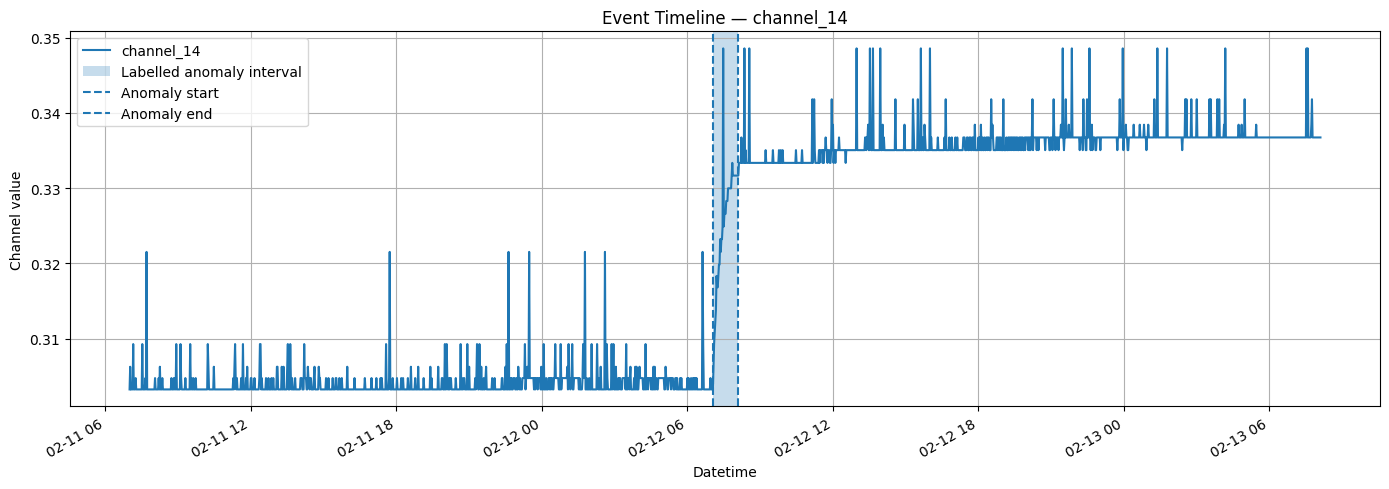

In [49]:
import matplotlib.pyplot as plt

# Choose one affected channel
channel_name = list(sliced_frame.keys())[1]
print(sliced_frame)
# Get the stored information
channel_info = sliced_frame[channel_name]
channel_df = channel_info["data"]
event_start = channel_info["label_start"]
event_end = channel_info["label_end"]

# The channel DataFrame should normally contain one value column
value_column = channel_df.columns[0]

# Create the plot
fig, ax = plt.subplots(figsize=(14, 5))

# Plot the channel signal
ax.plot(
    channel_df.index,
    channel_df[value_column],
    label=channel_name
)

# Shade the labelled anomaly interval
ax.axvspan(
    event_start,
    event_end,
    alpha=0.25,
    label="Labelled anomaly interval"
)

# Mark the exact start and end
ax.axvline(
    event_start,
    linestyle="--",
    label="Anomaly start"
)

ax.axvline(
    event_end,
    linestyle="--",
    label="Anomaly end"
)

# Labels and title
ax.set_title(f"Event Timeline — {channel_name}")
ax.set_xlabel("Datetime")
ax.set_ylabel("Channel value")

ax.legend()
ax.grid(True)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

In [45]:
read_channel_1 = pd.read_pickle("/Volumes/StudyNProjects/Python/ESA-Mission1/channels/channel_1")
#print(read_channel_1.index.min())
#print(read_channel_1.index.max())
sampling = read_channel_1.index.to_series().diff().value_counts()
print(sampling)

datetime
0 days 00:00:03           5090952
0 days 00:01:30           4659101
0 days 00:00:03.003000     221902
0 days 00:00:02.991000     166196
0 days 00:00:00.006000     125522
                           ...   
0 days 00:05:17.997000          1
0 days 00:00:53.742000          1
0 days 00:00:36.258000          1
0 days 00:00:00.111000          1
0 days 00:00:58.242000          1
Name: count, Length: 1208, dtype: int64


In [12]:
#print(read_channel_1)
#d.date_range(start='2026-01-01', periods=5, freq='D'
#check_time_diff = read_channel_1.index.diff()
read_channel_1["time_diff"] = read_channel_1.index.to_series().diff()
print(read_channel_1)
read_channel_1["gap_changed"]=(
    read_channel_1["time_diff"].ne(read_channel_1["time_diff"].shift())
)
check_time_diff = read_channel_1.loc[read_channel_1["gap_changed"],["time_diff"]]
print(check_time_diff)

                         channel_1       time_diff
datetime                                          
2000-01-01 00:00:02.805    0.13791             NaT
2000-01-01 00:01:32.805    0.13791 0 days 00:01:30
2000-01-01 00:03:02.805    0.13791 0 days 00:01:30
2000-01-01 00:04:32.805    0.13791 0 days 00:01:30
2000-01-01 00:06:02.805    0.13791 0 days 00:01:30
...                            ...             ...
2013-12-31 23:53:56.109    0.13791 0 days 00:01:30
2013-12-31 23:55:26.109    0.13791 0 days 00:01:30
2013-12-31 23:56:56.109    0.13791 0 days 00:01:30
2013-12-31 23:58:26.109    0.13791 0 days 00:01:30
2013-12-31 23:59:56.109    0.13791 0 days 00:01:30

[10513336 rows x 2 columns]
                                     time_diff
datetime                                      
2000-01-01 00:00:02.805                    NaT
2000-01-01 00:01:32.805        0 days 00:01:30
2000-01-18 08:15:02.802 0 days 00:01:29.997000
2000-01-18 08:16:32.805 0 days 00:01:30.003000
2000-01-18 08:18:02.802 0 